In [58]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.abspath("../.."))
from quantile_forest import RandomForestQuantileRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from tinyconformal.regressor import ConformalizedQuantileRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np
from tinyconformal.utils import MultiQuantileRegressor

In [59]:
EXAMPLES_DIR = Path.cwd().parent
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))
from utils.plot_utils import plot_prediction_intervals

In [60]:
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target


In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_calib, y_train, y_calib = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [62]:
coverage = 0.90
alpha = 1 - coverage
quantiles = [alpha/2, 1 - alpha/2]

In [63]:
rf = RandomForestQuantileRegressor(random_state=42, default_quantiles=quantiles, n_jobs=-1, oob_score=True, max_depth=int(np.ceil(np.log2(len(X_train)) - 1)))
rf.fit(X_train, y_train)

,n_estimators,100
,default_quantiles,"[0.04999999999999999, 0.95]"
,criterion,'squared_error'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,1
,max_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [64]:
rf.predict(X_test)

array([[0.4169 , 0.612  ],
       [0.521  , 1.59025],
       [3.1    , 5.00001],
       ...,
       [2.458  , 5.00001],
       [0.56165, 0.856  ],
       [1.15305, 2.2229 ]], shape=(4128, 2))

In [65]:
reg = ConformalizedQuantileRegressor(
    rf,
    alpha=alpha,
)
reg.fit(X_train, y_train, oob=True)

,learner,RandomForestQ...ndom_state=42)
,alpha,0.09999999999999998
,n_estimators,100
,default_quantiles,"[0.04999999999999999, 0.95]"
,criterion,'squared_error'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,1
,max_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0


In [66]:
reg

,learner,RandomForestQ...ndom_state=42)
,alpha,0.09999999999999998
,n_estimators,100
,default_quantiles,"[0.04999999999999999, 0.95]"
,criterion,'squared_error'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,1
,max_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0


In [67]:
y_pred_intervals = reg.predict_interval(X_test, alpha=0.2)
y_pred = reg.predict(X_test, alpha=0.2)

In [68]:
reg.evaluate(X_test, y_test, alpha=0.2)

{'total': 4128,
 'alpha': 0.2,
 'beta': None,
 'coverage_rate': np.float64(0.727),
 'interval_width_mean': np.float64(1.036),
 'mwis': np.float64(1.624),
 'mae': np.float64(0.33),
 'mbe': np.float64(-0.039),
 'mse': np.float64(0.273)}

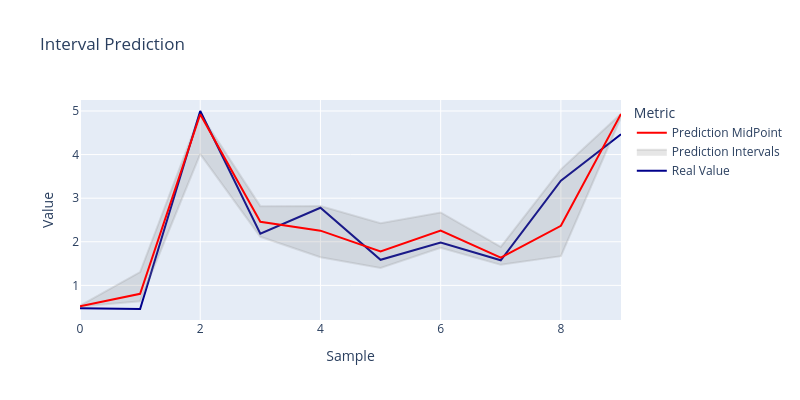

In [69]:
plot_prediction_intervals(y_pred_intervals[:10], y_pred[:10], y_test[:10], fig_type="png")

# MultiQuantileRegressor - HistGradientBoostingRegressor

In [70]:
mq_model = MultiQuantileRegressor(
        base_estimator=HistGradientBoostingRegressor(loss="quantile", random_state=42),
        quantiles=(0.1, 0.50, 0.90),
    )
mq_model.fit(X_train, y_train)
cqr = ConformalizedQuantileRegressor(learner=mq_model, alpha=0.2)
cqr.fit(X_calib, y_calib)

,learner,"MultiQuantile....1, 0.5, 0.9))"
,alpha,0.2
,loss,'quantile'
,quantile,None
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0


In [71]:
cqr.predict_interval(X_test)

array([[0.425304  , 0.89578584],
       [0.64923525, 1.32588339],
       [2.48892949, 5.34804181],
       ...,
       [4.32476799, 5.04057529],
       [0.56133473, 0.99623288],
       [1.4070303 , 2.14014181]], shape=(4128, 2))

In [72]:
cqr.evaluate(X_test, y_test)

{'total': 4128,
 'alpha': 0.2,
 'beta': None,
 'coverage_rate': np.float64(0.795),
 'interval_width_mean': np.float64(1.021),
 'mwis': np.float64(1.575),
 'mae': np.float64(0.323),
 'mbe': np.float64(-0.059),
 'mse': np.float64(0.262)}

In [73]:
bounds = cqr.predict_interval(X_test)
y_pred = cqr.predict(X_test)

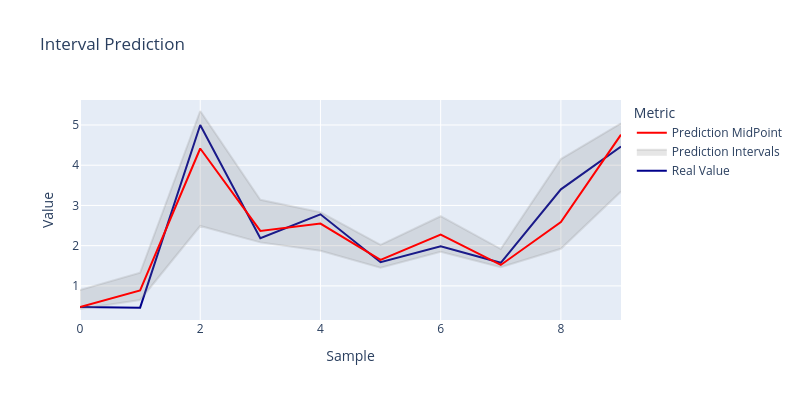

In [74]:
plot_prediction_intervals(bounds[:10], y_pred[:10], y_test[:10], fig_type="png")